인터넷 영화 데이터베이스(Internet Movie DataBase, IMDB)는 영화와 관련된 정보와 출연진 정보, 개봉 정보, 영화 후기, 평점까지 매우 폭넓은 데이터가 저장된 자료이다.  
2만 5,000여 개의 영화 리뷰가 담겨 있으며, 해당 영화를 긍정적으로 평가했는지 부정적으로 평가했는지 담겨 있다.

In [1]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

# 테스트셋을 지정한다.
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)

X_train = sequence.pad_sequences(x_train, maxlen=500)
X_test = sequence.pad_sequences(x_test, maxlen=500)

이제 모델을 다음과 같이 설정한다. model.summary() 함수를 이용해 현재 설정된 모델의 구조를 살펴본다.

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Embedding, LSTM, Conv1D, MaxPooling1D

# 모델의 구조를 설정한다.
model = Sequential()
model.add(Embedding(5000, 100))
model.add(Conv1D(64, 5, padding='valid', activation='relu', strides=1))
model.add(MaxPooling1D(pool_size=4))
model.add(LSTM(55))
model.add(Dense(1))
model.add(Activation('sigmoid'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 100)         500000    
                                                                 
 conv1d (Conv1D)             (None, None, 64)          32064     
                                                                 
 max_pooling1d (MaxPooling1  (None, None, 64)          0         
 D)                                                              
                                                                 
 lstm (LSTM)                 (None, 55)                26400     
                                                                 
 dense (Dense)               (None, 1)                 56        
                                                                 
 activation (Activation)     (None, 1)                 0         
                                                        

Conv1D는 컨볼루션 층이 1차원이고 배열도 1차원이다. 커널이 지나가면서 원래의 1차원 배열에 가중치를 각각 곱해 새로운 층인 컨볼루션 층을 만든다.  
MaxPooling1D 역시 마찬가지이다. 2차원 배열을 1차원으로 바꾸어 정해진 구역 안에서 가장 큰 값을 다음 층으로 넘기고 나머지는 버린다.

실습| LSTM과 CNN을 조합해 영화 리뷰 분류하기

Epoch 1/100
469/469 [==============================] - 79s 157ms/step - loss: 0.4069 - accuracy: 0.7985 - val_loss: 0.2876 - val_accuracy: 0.8846
Epoch 2/100
469/469 [==============================] - 27s 59ms/step - loss: 0.2382 - accuracy: 0.9079 - val_loss: 0.2774 - val_accuracy: 0.8803
Epoch 3/100
469/469 [==============================] - 13s 29ms/step - loss: 0.1885 - accuracy: 0.9290 - val_loss: 0.2649 - val_accuracy: 0.8912
Epoch 4/100
469/469 [==============================] - 12s 25ms/step - loss: 0.1464 - accuracy: 0.9470 - val_loss: 0.2892 - val_accuracy: 0.8835
Epoch 5/100
469/469 [==============================] - 11s 22ms/step - loss: 0.1228 - accuracy: 0.9565 - val_loss: 0.2955 - val_accuracy: 0.8880
Epoch 6/100
782/782 [==============================] - 3s 4ms/step - loss: 0.3521 - accuracy: 0.8819

 Test Accuracy 0.8819


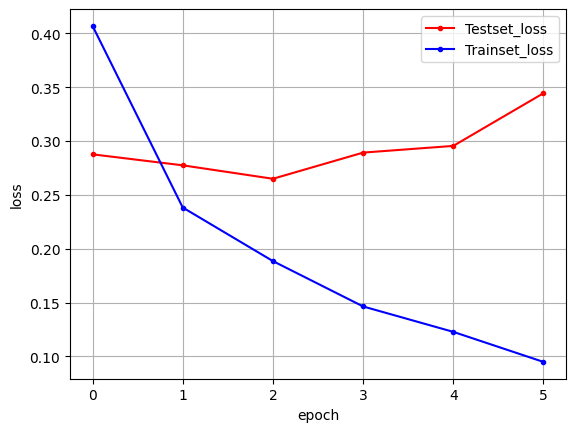

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Embedding, LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 데이터를 불러와 학습셋, 테스트셋으로 나눈다.
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=5000)

# 단어의 수를 맞춘다.
X_train = sequence.pad_sequences(X_train, maxlen=500)
X_test = sequence.pad_sequences(X_test, maxlen=500)

# 모델의 구조를 설정한다.
model = Sequential()
model.add(Embedding(5000, 100))
model.add(Dropout(0.5))
model.add(Conv1D(64, 5, padding='valid', activation='relu', strides=1))
model.add(MaxPooling1D(pool_size=4))
model.add(LSTM(55))
model.add(Dense(1))
model.add(Activation('sigmoid'))

# 모델의 실행 옵션을 정한다.
model.compile(loss='binary_crossentropy', optimizer='adam',
              metrics=['accuracy'])

# 학습의 조기 중단을 설정한다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=3)

# 모델을 실행한다.
history = model.fit(X_train, y_train, batch_size=40, epochs=100,
                    validation_split=0.25, callbacks=[early_stopping_callback])

# 테스트 정확도를 출력한다.
print("\n Test Accuracy %.4f" % (model.evaluate(X_test, y_test)[1]))

# 검증셋과 학습셋의 오차를 저장한다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 본다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시한다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()